###AIRO Logistic Regression Example
Binary Classification of Movie Reviews
(Positive/Negative)

Created by Caden Wondell

Step 1: Mount to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Step 2: Import Required Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

Step 3: Load and Preview the Dataset

In [ ]:
data = pd.read_csv(
    "/content/drive/MyDrive/Colab_Notebooks/AIRO_CLUB/Examples/IMDB_Movie_Review_Dataset.csv"
)
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


Step 4: Select the Feature and Target

In [ ]:
# Feature: movie review text
X = data["review"]

# Target: positive or negative sentiment
y = data["sentiment"]

Step 5: Split the Data into Training and Testing Sets

In [ ]:
#Split data into Training and Testing datasets, Training is 80%, Testing is 20%
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Step 6: Convert the Reviews into Numbers

In [ ]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

Step 7: Create and Train the Logistic Regression Model

In [ ]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

Step 8: Make Predictions

In [ ]:
predictions = model.predict(X_test_tfidf) #Make Predictions

predictions[:5] #Show the first 5 predictions

array(['negative', 'positive', 'negative', 'positive', 'negative'],
      dtype=object)

Step 9: Compare Predicted and Actual Scores

In [ ]:
results = pd.DataFrame({
    "Review": X_test,
    "Actual Sentiment": y_test,
    "Predicted Sentiment": predictions
})

results.head(10) #Compare Predictions vs Real scores

,Review,Actual Sentiment,Predicted Sentiment
33553,I really liked this Summerslam due to the look...,positive,negative
9427,Not many television shows appeal to quite as m...,positive,positive
199,The film quickly gets to a major chase scene w...,negative,negative
12447,Jane Austen would definitely approve of this o...,positive,positive
39489,Expectations were somewhat high for me when I ...,negative,negative
42724,I've watched this movie on a fairly regular ba...,positive,positive
10822,For once a story of hope highlighted over the ...,positive,positive
49498,"Okay, I didn't get the Purgatory thing the fir...",positive,negative
4144,I was very disappointed with this series. It h...,negative,negative
36958,The first 30 minutes of Tinseltown had my fing...,negative,negative


Step 10: Evaluate the Model

In [ ]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", round(accuracy * 100, 2), "%")

Accuracy: 89.99 %


Step 11: Visualize Classification Results

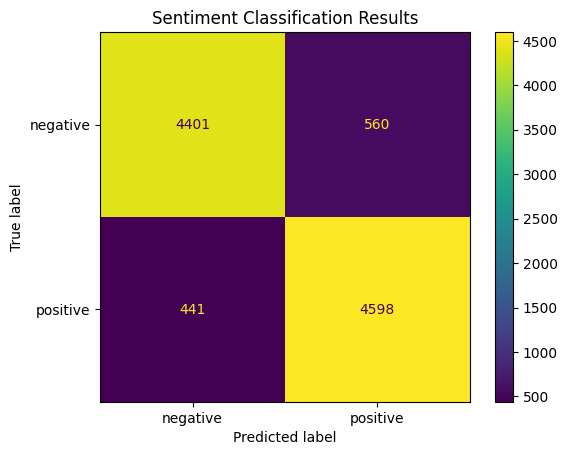

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    predictions
)

plt.title("Sentiment Classification Results")
plt.show()

Step 12: Test Your Own Movie Review

In [ ]:
new_review = [
    "This movie was amazing and I loved every minute of it."
]

new_review_tfidf = vectorizer.transform(new_review)

prediction = model.predict(new_review_tfidf)

print("Review:", new_review[0])
print("Predicted Sentiment:", prediction[0])

Review: This movie was amazing and I loved every minute of it.
Predicted Sentiment: positive
